= FIGURE 4

In [13]:
import simulations_temporalSBM as simulations
import dataprocessingSocioPattern as dataProcessing


import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, adjusted_rand_score, adjusted_mutual_info_score

In [14]:
dataset = 'high school 2011'
#The figures of the paper feature: 'high school 2011', 'high school 2012', 'high school 2013'
# But other possible choices: 'workplace 2013', 'workplace 2015' and 'primary school'

algos = [ 'Algorithm 2', 'ta-adjacency', 'ta-laplacian' ]

In [15]:
if dataset == 'high school 2011':
    communities =  [ ['PC'], ['PC*'], ['PSI*'] ]
    xticks = [ 0, 1000, 2000, 3000, 4000, 5000 ]
elif dataset == 'high school 2012':
    communities =  [ ['PC'], ['PC*'], ['MP*1'], ['MP*2'], ['PSI*'] ]
    xticks = [ 0, 2000, 4000, 6000, 8000, 10000 ]
    xticks = [ 0, 3000, 6000, 9000, 12000 ]
elif dataset == 'high school 2013':
    communities = [ ['2BIO1'], ['2BIO2'], ['2BIO3'], ['MP*1'], ['MP*2'], ['MP'], ['PC'], ['PC*'], ['PSI*'] ]
    xticks = [0, 1500, 3000, 4500, 6000]
    xticks = [0, 2500, 5000, 7500 ]
elif dataset == 'workplace 2013':
    communities = [ ['DISQ'], ['DSE'], ['DMCT'], ['SRH'] ]
    xticks = [0, 1500, 3000, 4500, 6000]
elif dataset == 'workplace 2015':
    communities = [ ['DISQ'],['DMCT'],['DMI'],['DSE'],['DST'] ]
    xticks = [0, 4000, 8000, 12000, 16000]
elif dataset == 'primary school':
    communities = [ ['1A'], ['1B'], ['2A'], ['2B'], 
               ['3A'], ['3B'], ['4A'], ['4B'], 
               ['5A'], ['5B'] ]
    xticks = [0, 1000, 2000, 3000 ]
else:
    raise TypeError( 'The dataset is not implemented' )


498  edges have been dropped
Algorithm 2


100%|██████████| 269/269 [00:00<00:00, 1402.56it/s]


ta-adjacency


100%|██████████| 269/269 [00:00<00:00, 1061.53it/s]


ta-laplacian


  0%|          | 0/5390 [00:00<?, ?it/s]/opt/anaconda3/envs/graph/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/envs/graph/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/envs/graph/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/envs/graph/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/envs/graph/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connecte

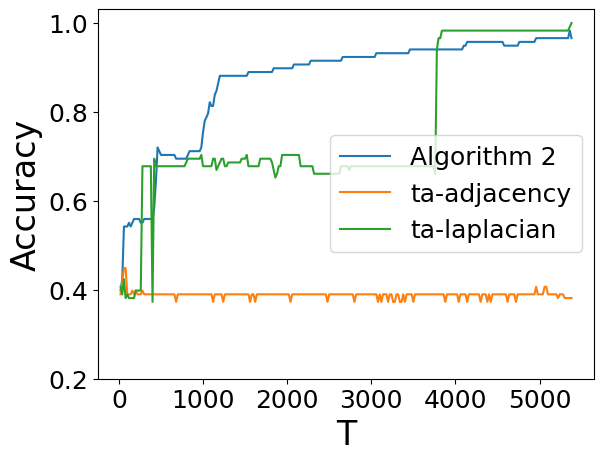

In [16]:
temporal_edges_days, labels_true, labels = dataProcessing.dataProcessingSocioPatterns( dataset = dataset, 
                                                                                      communities = communities,
                                                                                      keepNonInteractingPeriods = False )

t = 0
temporal_edges = dict( )
for day in temporal_edges_days.keys( ):
    for u in temporal_edges_days[ day ]:
        temporal_edges[ t ] = temporal_edges_days[ day ][ u ]
        t += 1
      
        
K = len( set( labels_true ) )
if K != len( communities):
    print( 'There is a problem in the number of communities' )
N = len(labels_true)
T = len( temporal_edges )

adjacencyTensor = np.zeros( ( N, N, T ), dtype = int )
for t in range( T ):
    for edge in temporal_edges[t]:
        adjacencyTensor[ edge[0], edge[1], t ] = 1
        adjacencyTensor[ edge[1], edge[0], t ] = 1

step = 20


predicted_labels = dict( )
aris = dict( )
accuracies = dict( )
for algo in algos:
    print( algo )
    predicted_labels[ algo ] = simulations.clustering( algo, adjacencyTensor, n_clusters = K, step = step, tqdm_ = True )
    aris[ algo ] = [ ]
    accuracies[ algo ] = [ ]
    for t in tqdm( range( predicted_labels[algo].shape[1] ) ):
        aris[algo].append( adjusted_rand_score( labels_true, predicted_labels[algo][ :,t ] ) )
        accuracies[algo].append( simulations.computeAccuracy( labels_true, predicted_labels[algo][ :,t ] ) )


x = [ t for t in range( step, T, step ) ]

yticks = np.arange( 0.2, 1.01, step = 0.2 )

simulations.plotting( x, accuracies, xticks = xticks,
         yticks = yticks,
             curves_errors = None,
             legendTitle = '', figTitle = '',
             xlabel = 'T', ylabel = 'Accuracy',
             saveFig = False, fileName = 'sociopatterns_' + dataset.replace(" ", "") + '.pdf' )
